# Module 1: Exploratory Data Analysis on NVIDIA Nemotron-Agentic-Tool-Use-v1

**Author:** Kirk Kennedy Lincoln

**Dataset:** NVIDIA Nemotron-Agentic-Tool-Use-v1

This project performs exploratory data analysis on agentic AI policy execution data from NVIDIA's Nemotron dataset. The analysis covers data ingestion, cleaning, domain extraction, and visualization of tool usage patterns across four agent policy domains.

## Setup

### Environment
Create a virtual environment and install dependencies before launching this notebook.
See [Install Instructions](https://packaging.python.org/en/latest/guides/installing-using-pip-and-virtual-environments/) for more details.
```bash
python -m venv venv
source venv/bin/activate  # Windows: venv\Scripts\activate
pip install -r requirements.txt
python -m ipykernel install --user --name=agent-eda
```

Then select the **agent-eda** kernel in Jupyter before running.


##### Note: 
You must install and configure the kernel externally before running this notebook.

In [1]:
import ast
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

## Data Ingestion

In order to have the proper file for this notebook to run, please execute the next cell.

In [2]:
df = pd.read_csv('agent_data.csv')
df['tools_called'] = df['tools_called'].apply(ast.literal_eval)
print("======HEAD======")
print(df.head())
print("\n\n======INFO======")
print(df.info())

======HEAD======
                                   uuid  num_turns  \
0  ff6ab2b0-7551-468c-8606-a7c3b0c75b68          5   
1  091a4c59-2ffa-4a65-b243-696155c57684         17   
2  596943ce-b426-4f33-bdd1-4cce7185fe46          5   
3  78450da8-49f2-4389-8253-4c5597831a44          5   
4  d3c4bb85-f770-434d-9030-3471c8bf2952          5   

                                       system_prompt  \
0  You are a customer service agent that helps th...   
1  You are a customer service agent that helps th...   
2  You are a customer service agent that helps th...   
3  You are a customer service agent that helps th...   
4  You are a customer service agent that helps th...   

                         tools_called  num_user  num_assistant  num_tool  \
0                 [authenticate_user]         1              2         1   
1  [verify_guest_order, cancel_order]         6              8         2   
2          [transfer_to_human_agents]         1              2         1   
3          [trans

### Ingestion Function
As anyone can see, our dataset is actually a collection of json strings!  We were able to count frequencies of user's message count, the amount of tools call, and finding it all reliably.
 
 0   uuid            19028 non-null  object
 1   num_turns       19028 non-null  int64 
 2   system_prompt   19028 non-null  object
 3   tools_called    19028 non-null  object
 4   num_user        19028 non-null  int64 
 5   num_assistant   19028 non-null  int64 
 6   num_tool        19028 non-null  int64 
 7   num_system      19028 non-null  int64 
 8   num_tool_calls  19028 non-null  int64 
 9   license         19028 non-null  object
 10  has_reasoning   19028 non-null  bool    


* uuid: is important to track individual instances
* num_turns: preserves the number of total interactions (user & agent messages/actions)
* system_prompt: preserves the original agentic policy executed
* tools_called: provides a list of all tools called during policy execution
* num_user: preserves the total number of user initiated messages
* num_assistant: preserves the total number of agent initiated messages
* num_tool: preserves the total number of tool calls initiated
* num_system: this field is for validation, there should only be 1 system message in each policy
* num_tool_calls: total number of tool calls to support filtering the DataFrame
* license: important for legal details and any additional analysis for more diverse datasets
* has_reasoning: flags whether the policy has reasoning, good for training data

#### Data Details
There aren't any floats in this dataset and all numbers are integers or objects.

Has reasoning signals whether this agent is using ReACT or not.

## Data Cleaning

In [3]:
def extract_domain(prompt):
    """Extract agent domain name from system prompt bold header.
    
    Parses the first bold-formatted policy title (e.g., '**Food Delivery 
    Agent Policy**') and returns the raw string.
    
    Args:
        prompt (str): Raw system prompt text.
    
    Returns:
        str or NaN: Normalized domain name, or NaN if no match found.
    """
    import re
    match = re.search(r'\*\*(.+?Policy)\*\*', prompt)
    if match:
        return match.group(1).strip()
    return np.nan

def normalize_tool_name(agent_df):
    """Standardizes the final "Escalation" step in an agent's workflow
    
    Explodes the dataframe and remaps the agentic Human-in-the-Loop step
    to a normalized name.
    
    Args:
        agent_df (pd.DataFrame): Complete DataFrame for ease of mutation.
    
    Returns:
        pd.DataFrame: crosstab application containing the exploded columns.
    """
    tools_exploded = agent_df[["domain", "tools_called"]].explode("tools_called")
    tools_exploded = tools_exploded[tools_exploded["tools_called"].notna()]
    
    # Necessary cleaning step since these tool calls relate to a human-in-the-loop call.
    tool_renames = {
        "transfer_to_human_agents": "transfer_to_human_agent",
        "transfer_to_triage_nurse": "transfer_to_human_agent",
    }
    tools_exploded["tools_called"] = tools_exploded["tools_called"].replace(tool_renames)
    
    return pd.crosstab(
        tools_exploded["tools_called"], 
        tools_exploded["domain"], 
        normalize="columns"
    )

df["domain"] = df["system_prompt"].apply(extract_domain)

# We will be dropping NaNs for the whole row since the domain series
# is central to our data visualization and importance of the dataset.
# The cleaning here is necessary since we know that rows missing the
# domain are most likely errors or lacking data we care about currently.
agent_df = df.dropna(subset=['domain'])
filtered_agent_len = len(agent_df[agent_df.notna()])

print("Have we cleaned all NaNs for our domain series?")
print(f"Yes! the agent_df has {len(agent_df)} rows and agent_df[agent_df.notna()] has {filtered_agent_len}") if  filtered_agent_len == len(agent_df) else print("NO! Something is very wrong!")

Have we cleaned all NaNs for our domain series?
Yes! the agent_df has 13935 rows and agent_df[agent_df.notna()] has 13935


### Cleaning Function 1
extract_domain is the first cleaning function that supports finding all "domains" that the policy belongs to.  These are labeled as Domains so the logic followed that we should preserve those details about each entry.  The majority of our analysis will lean on domains so this cleaning function is seen as essential and resuable, so much so, we use it in an apply().

### Cleaning Function 2

normalize_tool_name is the second cleaning function, which is essential to formatting data later on.  Our Human-in-the-Loop escalation tag is named differently based upon the domain in two cases.  Therefore, we explode the DataFrame based upon "tools_called" and remove any NaNs.  We then use the replace function to apply our dict to filter and map our strings to one string "transfer_to_human_agent".  Everything is packaged together into crosstab, which produces our DataFrame to demonstrate our data in a heatmap.  We need this function to normalize this stat since it is the equivalent of the "finish line" where an agent's job is to escalate to a human, which will most likely end in a completion of a task.

## Exploratory Data Analysis

In [4]:
def summarize_dataset(df):
    """Summarize key characteristics of the agent policy dataset.
    
    Computes policy tag coverage, reasoning flag distribution,
    and license variety across all records.
    
    Args:
        df (pd.DataFrame): Cleaned agent policy DataFrame.
    
    Returns:
        None: Prints summary statistics.
    """
    # Showing an example of the raw policy text we could parse and categorize
    print("\n\n======AGENT POLICY======")
    # Viewing the number of valid data tags that drives viability of the row
    has_policy = df["system_prompt"].str.contains("Domain Basics").sum()
    print(f"{has_policy} / {len(df)} prompts have a domain present")
    print("\n\n======HAS REASONING======")
    has_reasoning = df["has_reasoning"].sum()
    print(f"{has_reasoning} / {len(df)} prompts have reasoning enabled")
    print("\n\n======LICENSE FREQUENCY======")
    license_variety = df["license"].value_counts()
    print(f"{license_variety}")

summarize_dataset(df)



======AGENT POLICY======
17511 / 19028 prompts have a domain present


======HAS REASONING======
19028 / 19028 prompts have reasoning enabled


======LICENSE FREQUENCY======
license
cc-by-4.0    19028
Name: count, dtype: int64


## Visualizations

domain
Food Delivery Agent Policy                 4634
Ride-Sharing Agent Policy                  4249
Hospitality (Hotel/Resort) Agent Policy    3910
Healthcare Appointment Agent Policy        1142
Name: count, dtype: int64


[Text(0, 0, 'Food Delivery Agent Policy'),
 Text(1, 0, 'Healthcare Appointment Agent Policy'),
 Text(2, 0, 'Hospitality (Hotel/Resort) Agent Policy'),
 Text(3, 0, 'Ride-Sharing Agent Policy')]

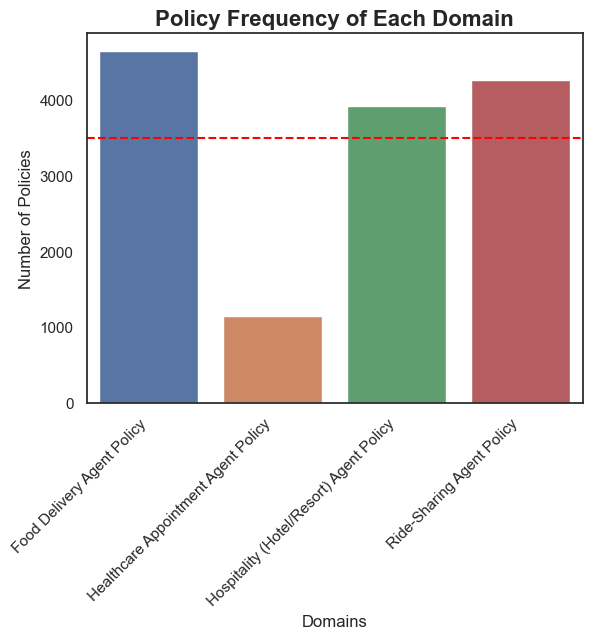

In [5]:
sns.set_theme(style="white")
domain_counts = agent_df["domain"].value_counts()
print(domain_counts)
avg = domain_counts.sum()/len(domain_counts)
ax = sns.countplot(data=agent_df, x="domain", hue="domain")
ax.set_title("Policy Frequency of Each Domain", fontsize=16, fontweight="bold")
ax.set_xlabel("Domains", fontsize=12)
ax.set_ylabel("Number of Policies", fontsize=12)
ax.axhline(y=avg, color="red", linestyle="--", label="threshold")
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

### Interpretation
After observing the average we see it listed around 3500. Healthcare seems to be overwhelmed by the remaining domain categories with Food Delivery being the highest amount overall.  Therefore, we need to keep in mind that healthcare representations might be lacking enough data to represent the domain category correctly.  Fortunately Seaborn provides different visualizations that help display these inadequacies in our dataset.

Text(0, 0.5, 'Total Number of User Messages')

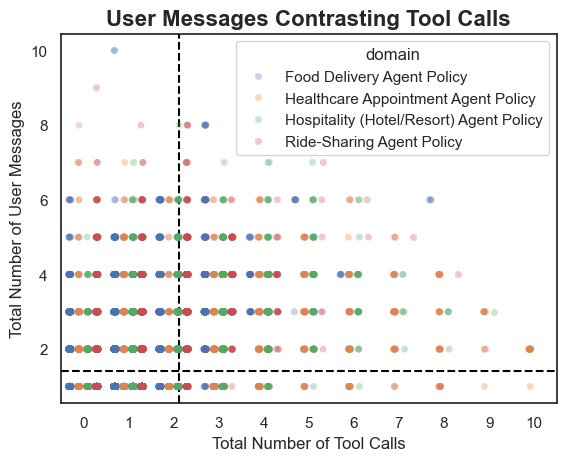

In [6]:
bx = sns.stripplot(data=agent_df, x="num_tool_calls", y="num_user", 
              hue="domain", dodge=True, alpha=0.3, jitter=True)
user_messages_avg = agent_df["num_user"].mean()
tool_calls_avg = agent_df["num_tool"].mean()
bx.axhline(y=tool_calls_avg, color="black", linestyle="--", label="threshold")
bx.axvline(x=user_messages_avg, color="black", linestyle="--", label="threshold")
bx.set_title("User Messages Contrasting Tool Calls", fontsize=16, fontweight="bold")
bx.set_xlabel("Total Number of Tool Calls", fontsize=12)
bx.set_ylabel("Total Number of User Messages", fontsize=12)

### Interpretation
Due to the discrete nature of what we are looking at, most of this data will be compressed (thousands of units all in one section of the graph).  However, using a stripplot we can see that the range of 4 users crossectioned by 2 tool calls carries a strong majority of all 4 categories.  When viewing the healthcare appointment hues it seems they struggle from excessive tool call, strongly correlated with hospitality policies compared to food delivery and ride-sharing.  Food delivery tends to have a higher count of user messages and carries some of the largest outlier data points (10 x 1, 8 x 3, 6 x 8).  Therefore, I would interpret this as food service being less efficient when it comes to escalations and possible issues in their customer service.  Ride-sharing seems to be the most efficient agent policy producing few visual outliers and having a tight grouping for lower number of user messages and number of overall tools called.

[Text(0.5, 0, 'Food Delivery Agent Policy'),
 Text(1.5, 0, 'Healthcare Appointment Agent Policy'),
 Text(2.5, 0, 'Hospitality (Hotel/Resort) Agent Policy'),
 Text(3.5, 0, 'Ride-Sharing Agent Policy')]

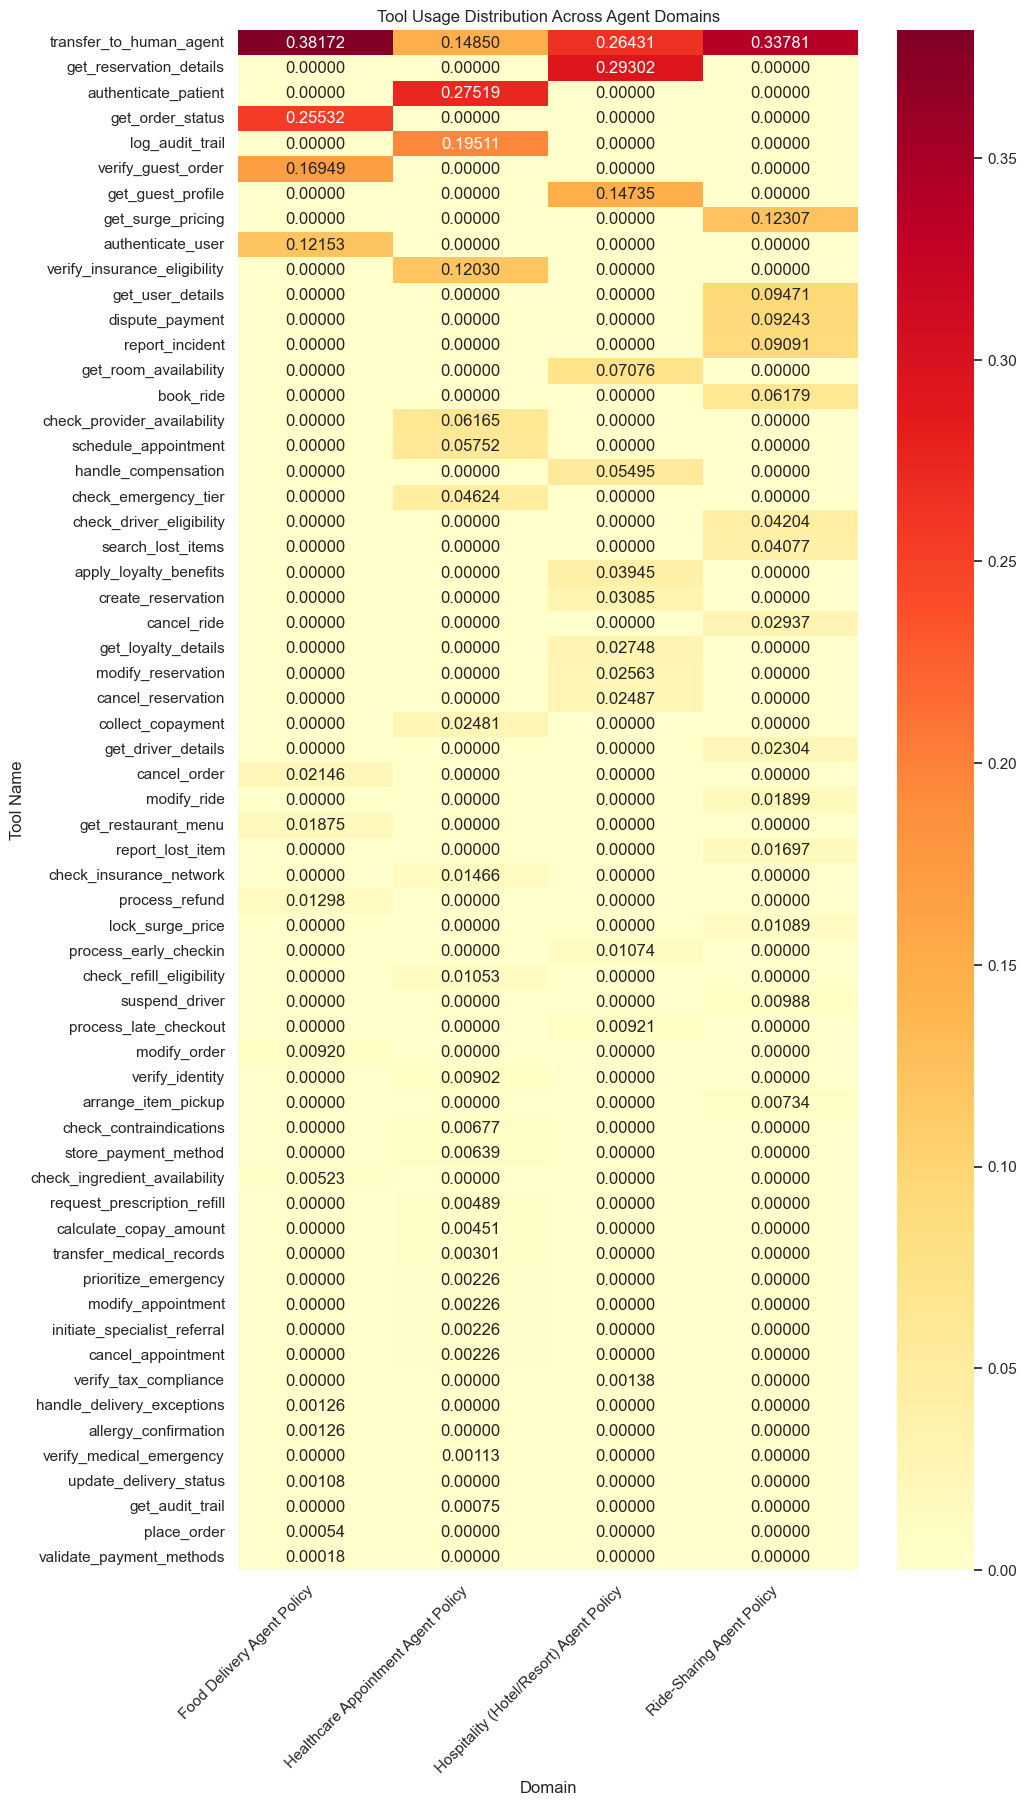

In [7]:
tool_matrix = normalize_tool_name(agent_df)
tool_matrix = tool_matrix.loc[tool_matrix.sum(axis=1).sort_values(ascending=False).index]
plt.subplots(figsize=(10, 20))
cx = sns.heatmap(tool_matrix, annot=True, fmt=".5f", cmap="YlOrRd")
cx.set_title("Tool Usage Distribution Across Agent Domains")
cx.set_xlabel("Domain")
cx.set_ylabel("Tool Name")
cx.set_xticklabels(cx.get_xticklabels(), rotation=45, ha="right")

### Interpretation
When looking at the overall tool calls we can say the majority of them are low frequency or non-existent possibly because of the tool not existing in that domain.  However, we normalized the human-in-the-loop call so we can view the epitome of most tool calls since an agent's responsibility is most likely to terminate the task with a human.  The next category that sticks out is status checking of orders or service.

## Summary

### Data Bias
Bias can enter when parsing the agent's policy since some domains contain substeps that don't conform.

#### i.e. Healthcare
```
*Appointment Types*:  
1. **Emergency**: Requires immediate care (tier 1-3)  
2. **Urgent**: Within 24 hours  
3. **Routine**: 7+ day window  
4. **Follow-up**: Linked to previous visit  
```
#### i.e. Healthcare
```
**Cancellation Policy**  
| Time Before Appointment | Fee |  
|-------------------------|-----|  
| <24 hours | $50 |  
| <1 hour | $100 + copay |  
*Exceptions: Medical emergencies (requires MD note)*  
```

We can see that Healthcare tends to include a Cancellation Policy, which is technically counted correctly right now; however, this data could be counted in different ways, which could explain certain things as: higher tool calling, observed inefficiencies, and healthcare having a more difficult escalation path.  If we trained agents on some of the statistics from this dataset, then healthcare would be lacking the sufficient parsing to provide sufficient datapoints.  Looking back to our "Policy Frequency of Each Domain" healthcare is highly underrepresented and would need some sort of sampling and balancing if used for formal training.

### Insights
**Food Delivery**  

- Top 3 Tool Calls:  
    + transfer_to_human_agent  
    + get_order_status  
    + verify_guest_order
- Max User Messages: 10  
- Max Tool Call: 8
- Total Number of Policy Executions: 4634  

**Healthcare**  
- Top 3 Tool Calls:  
  + authenticate_patient  
  + log_audit_trail  
  + transfer_to_human_agent  
- Max User Messages: 8  
- Max Tool Call: 10
- Total Number of Policy Executions: 1142  
  
**Hospitality**  
- Top 3 Tool Calls:  
  + get_reservation_details  
  + transfer_to_human_agent  
  + get_guest_profile  
- Max User Messages: 7  
- Max Tool Call: 9
- Total Number of Policy Executions: 3910  
  
**Ride-Sharing**  
- Top 3 Tool Calls:  
    + transfer_to_human_agent  
    + get_surge_pricing  
    + get_user_details  
- Max User Messages: 9  
- Max Tool Call: 8  
- Total Number of Policy Executions: 4249  


### Patterns
The main pattern that sticks out are the four tool calls, which all seem to be correlated!

**verify_guest_order**  
**authenticate_patient**  
**get_reservation_details**  
**get_surge_pricing**  

Each of these tool calls are getting context on how the main service will interact with the customer:  
* *verify_guest_order* is validating that the user's order and if the order is being assembled in the correct fashion.
* *authenticate_patient* is validating the patient and their viability for access to triage.
* *get_reservation_details* is validating the user's reservation and their viability to be confirmed and booked.
* *get_surge_pricing* is validating the current trend in costs to ask the user if they would like to proceed.

The first three tool_calls strongly relate; consequently, *get_surge_pricing* is somewhat different in nature.  The tool call helps analyze the viability of offering a service.  Some services need a validation, such as: previously booking a reservation, having an ailment, possessing an order number, etc.  The observed trend indicates that agent utilization is largely concentrated on customer validation and access control decisions regarding service eligibility.  *get_user_details* was called ~9.4% of the time for ride-sharing policy executions.  Within the context of our heatmap *get_user_details* seems to be a supporting tool call, which verifies certain details about the user.  


### Assumptions 
I would assume the details surrounding *get_surge_pricing* can accomodate the historical interaction each user has had with the platform.  In addition, since *transfer_to_human_agent* is in the top 3 tool calls for each model, the main emphasis of each policy is to drive the agent towards Human-in-the-Loop escalation.  Effectively, policies that invoke a high number of tool calls should be reevaluated as being inefficient and policies that cause a high number of user messages should reevaluated for their conciseness of what is being communicated to the user.

### Limitations
*interactive_agent.jsonl* has a partner file with more context and details but our hardware was not able to support the loading of it into memory.  Instead of going down the road of working on ingestion for the majority of this project, I focused on what would be useful from *interactive_agent.jsonl* alone.  The size of the sister file is around 5gb.